In [1]:
cd /content/drive/MyDrive/VoteRE

/content/drive/MyDrive/VoteRE


# 1- Process RAW to CSV

In [ ]:
!python process_raw_to_csv.py \
    --input_dir "Data/0_raw/TACRED" \
    --output_dir "Data/1_processed/TACRED"

✔ Processed: Data/0_raw/TACRED/test.json -> Data/1_processed/TACRED/test.csv
✔ Processed: Data/0_raw/TACRED/dev.json -> Data/1_processed/TACRED/dev.csv
✔ Processed: Data/0_raw/TACRED/train.json -> Data/1_processed/TACRED/train.csv


In [ ]:
!python process_raw_to_csv.py \
    --input_dir "Data/0_raw/TACREV" \
    --output_dir "Data/1_processed/TACREV"

✔ Processed: Data/0_raw/TACREV/dev.json -> Data/1_processed/TACREV/dev.csv
✔ Processed: Data/0_raw/TACREV/test.json -> Data/1_processed/TACREV/test.csv


In [ ]:
!python process_raw_to_csv.py \
    --input_dir "Data/0_raw/ReTACRED" \
    --output_dir "Data/1_processed/ReTACRED"

✔ Processed: Data/0_raw/ReTACRED/test.json -> Data/1_processed/ReTACRED/test.csv
✔ Processed: Data/0_raw/ReTACRED/dev.json -> Data/1_processed/ReTACRED/dev.csv
✔ Processed: Data/0_raw/ReTACRED/train.json -> Data/1_processed/ReTACRED/train.csv


In [ ]:
!python process_raw_to_csv.py \
    --input_dir "/content/drive/MyDrive/Data/0_raw/Example" \
    --output_dir "/content/drive/MyDrive/Data/1_processed/Example"

# 1- Create Prompts

In [ ]:
!python processed_to_prompt.py \
    --input_dir "Data/1_processed/TACRED" \
    --output_dir "Data/2_prompts/TACRED" \
    --dataset_name TACRED

Building prompts from dev.csv: 22631it [00:00, 56855.51it/s]
Saved prompt JSON to: Data/2_prompts/TACRED/dev.json
Total prompts: 22631
Building prompts from test.csv: 15509it [00:00, 57617.14it/s]
Saved prompt JSON to: Data/2_prompts/TACRED/test.json
Total prompts: 15509
Building prompts from train.csv: 68124it [00:01, 54417.56it/s]
Saved prompt JSON to: Data/2_prompts/TACRED/train.json
Total prompts: 68124


In [ ]:
!python processed_to_prompt.py \
    --input_dir "Data/1_processed/TACREV" \
    --output_dir "Data/2_prompts/TACREV" \
    --dataset_name TACREV

Building prompts from dev.csv: 22631it [00:00, 49520.17it/s]
Saved prompt JSON to: Data/2_prompts/TACREV/dev.json
Total prompts: 22631
Building prompts from test.csv: 15509it [00:00, 56781.85it/s]
Saved prompt JSON to: Data/2_prompts/TACREV/test.json
Total prompts: 15509


In [ ]:
!python processed_to_prompt.py \
    --input_dir "Data/1_processed/ReTACRED" \
    --output_dir "Data/2_prompts/ReTACRED" \
    --dataset_name RETACRED

Building prompts from dev.csv: 19584it [00:00, 31487.50it/s]
Saved prompt JSON to: Data/2_prompts/ReTACRED/dev.json
Total prompts: 19584
Building prompts from test.csv: 13418it [00:00, 32095.35it/s]
Saved prompt JSON to: Data/2_prompts/ReTACRED/test.json
Total prompts: 13418
Building prompts from train.csv: 58465it [00:01, 40292.09it/s]
Saved prompt JSON to: Data/2_prompts/ReTACRED/train.json
Total prompts: 58465


In [ ]:
!python processed_to_prompt.py \
    --input_dir "Data/1_processed/Example" \
    --output_dir "Data/2_prompts/Example" \
    --dataset_name RETACRED

No CSV files found in: Data/1_processed/Example


# 3- LLM inference

In [ ]:
!python llm_inference_only.py \
    --prompts_dir Data/2_prompt/TACRED \
    --processed_dir Data/1_processed/TACRED \
    --output_dir Data/3_Voters_Predictions/QWEN/TACRED \
    --model_path LLM_Models/QWEN_TACRED/checkpoint-merged

In [ ]:
!python llm_inference_only.py \
    --prompts_dir Data/2_prompt/ReTACRED \
    --processed_dir Data/1_processed/ReTACRED \
    --output_dir Data/3_Voters_Predictions/QWEN/ReTACRED \
    --model_path LLM_Models/QWEN_RETACRED/checkpoint-merged

In [ ]:
!python llm_inference_only.py \
    --prompts_dir Data/2_prompt/ReTACRED \
    --processed_dir Data/1_processed/ReTACRED \
    --output_dir Data/3_Voters_Predictions/QWEN/ReTACRED \
    --model_path LLM_Models/QWEN_RETACRED/checkpoint-merged

# 4- Vote RE

In [ ]:
!python vote_re.py \
    --dataset TACRED \
    --split test \
    --voters LORA_QWEN LORA_LLAMA LORA_MISTRAL \
    --k 2 \
    --output_csv Data/4_VoteRE/TACRED/test_llm_vote_k2.csv

Voting on dataset=TACRED, split=test
Voters: ['LORA_QWEN', 'LORA_LLAMA', 'LORA_MISTRAL']
k = 2

Saved: Data/4_VoteRE/TACRED/test_llm_vote_k2.csv
Rows: 15509


In [ ]:
!python vote_re.py \
    --dataset TACREV \
    --split dev \
    --voters PLM_BERT_LARGE PLM_ROBERTA_LARGE PLM_SPANBERT_LARGE \
    --k 2 \
    --output_csv Data/4_VoteRE/TACREV/dev_plm_vote_k2.csv

Voting on dataset=TACREV, split=dev
Voters: ['PLM_BERT_LARGE', 'PLM_ROBERTA_LARGE', 'PLM_SPANBERT_LARGE']
k = 2

Saved: Data/4_VoteRE/TACREV/dev_plm_vote_k2.csv
Rows: 22631


In [ ]:
!python vote_re.py \
    --dataset ReTACRED \
    --split test \
    --voters PLM_ROBERTA_LARGE PLM_SPANBERT_LARGE LORA_QWEN LORA_LLAMA LORA_MISTRAL \
    --k 3 \
    --output_csv Data/4_VoteRE/ReTACRED/test_mixed_vote_k3.csv

Voting on dataset=ReTACRED, split=test
Voters: ['PLM_ROBERTA_LARGE', 'PLM_SPANBERT_LARGE', 'LORA_QWEN', 'LORA_LLAMA', 'LORA_MISTRAL']
k = 3

Saved: Data/4_VoteRE/ReTACRED/test_mixed_vote_k3.csv
Rows: 13418


# Analysis

In [ ]:
import pandas as pd
import scorer
from contextlib import redirect_stdout
import io
from pathlib import Path
from collections import Counter


def silent_score(gold, pred):
    f = io.StringIO()
    with redirect_stdout(f):
        p, r, f1 = scorer.score(gold, pred, verbose=False)
    return p, r, f1


def detect_prediction_column(df):
    if "LLM_Prediction" in df.columns:
        return "LLM_Prediction"
    if "Prediction" in df.columns:
        return "Prediction"
    raise ValueError("No prediction column found")


def majority_k(pred_lists, k=2, fallback="no_relation"):
    output = []
    for preds in zip(*pred_lists):
        counts = Counter(preds)
        label, count = counts.most_common(1)[0]
        if count >= k:
            output.append(label)
        else:
            output.append(fallback)
    return output


def full_majority(pred_lists, fallback="no_relation"):
    output = []
    for preds in zip(*pred_lists):
        if len(set(preds)) == 1:
            output.append(preds[0])
        else:
            output.append(fallback)
    return output


def evaluate_voter_group(base_dir, dataset, split, voters):
    print("=" * 80)
    print(f"Dataset: {dataset}")
    print(f"Split:   {split}")
    print(f"Voters:  {', '.join(voters)}")
    print("=" * 80)

    voter_predictions = {}
    gold_reference = None

    for voter in voters:
        file_path = Path(base_dir) / voter / dataset / f"{split}.csv"

        if not file_path.exists():
            print(f"Missing file: {file_path}")
            return

        df = pd.read_csv(file_path)
        pred_col = detect_prediction_column(df)

        gold = df["True_Labels"].tolist()
        preds = df[pred_col].tolist()

        if gold_reference is None:
            gold_reference = gold
        else:
            if gold_reference != gold:
                raise ValueError(f"Gold labels mismatch in file: {file_path}")

        voter_predictions[voter] = preds

    ordered_voters = list(voters)

    print("\n" + "-" * 80)
    print("[INDIVIDUAL VOTER RESULTS]")
    print("-" * 80)

    for voter in ordered_voters:
        p, r, f1 = silent_score(gold_reference, voter_predictions[voter])
        print(f"\n[{voter}]")
        print(f"Precision: {p:.3%}")
        print(f"Recall:    {r:.3%}")
        print(f"F1:        {f1:.3%}")

    pred_lists = [voter_predictions[v] for v in ordered_voters]

    pred_majority_k2 = majority_k(pred_lists, k=2)
    p_k2, r_k2, f1_k2 = silent_score(gold_reference, pred_majority_k2)

    print("\n" + "-" * 80)
    print("[MAJORITY WITH k=2]")
    print("-" * 80)
    print("Rule: if at least 2 voters agree on the same label, keep it; else no_relation")
    print(f"Precision: {p_k2:.3%}")
    print(f"Recall:    {r_k2:.3%}")
    print(f"F1:        {f1_k2:.3%}")

    pred_full_majority = full_majority(pred_lists)
    p_fm, r_fm, f1_fm = silent_score(gold_reference, pred_full_majority)

    print("\n" + "-" * 80)
    print("[FULL MAJORITY]")
    print("-" * 80)
    print("Rule: all voters must agree; otherwise no_relation")
    print(f"Precision: {p_fm:.3%}")
    print(f"Recall:    {r_fm:.3%}")
    print(f"F1:        {f1_fm:.3%}")

In [ ]:
BASE_DIR = "Data/3_Voters_Predictions"
DATASETS = ["TACRED", "TACREV", "ReTACRED"]
SPLITS = ["test"]

VOTERS = ["LORA_QWEN", "LORA_LLAMA", "LORA_MISTRAL"]

for dataset in DATASETS:
    for split in SPLITS:
        evaluate_voter_group(BASE_DIR, dataset, split, VOTERS)

Dataset: TACRED
Split:   test
Voters:  LORA_QWEN, LORA_LLAMA, LORA_MISTRAL

--------------------------------------------------------------------------------
[INDIVIDUAL VOTER RESULTS]
--------------------------------------------------------------------------------

[LORA_QWEN]
Precision: 75.657%
Recall:    76.180%
F1:        75.918%

[LORA_LLAMA]
Precision: 77.820%
Recall:    73.654%
F1:        75.680%

[LORA_MISTRAL]
Precision: 77.656%
Recall:    74.316%
F1:        75.949%

--------------------------------------------------------------------------------
[MAJORITY WITH k=2]
--------------------------------------------------------------------------------
Rule: if at least 2 voters agree on the same label, keep it; else no_relation
Precision: 77.847%
Recall:    75.248%
F1:        76.525%

--------------------------------------------------------------------------------
[FULL MAJORITY]
--------------------------------------------------------------------------------
Rule: all voters must ag

In [ ]:
BASE_DIR = "Data/3_Voters_Predictions"
DATASETS = ["TACRED", "TACREV", "ReTACRED"]
SPLITS = ["test"]

VOTERS = ["PLM_DEBERTA_LARGE", "PLM_ROBERTA_LARGE", "PLM_SPANBERT_LARGE"]

for dataset in DATASETS:
    for split in SPLITS:
        evaluate_voter_group(BASE_DIR, dataset, split, VOTERS)

Dataset: TACRED
Split:   test
Voters:  PLM_DEBERTA_LARGE, PLM_ROBERTA_LARGE, PLM_SPANBERT_LARGE

--------------------------------------------------------------------------------
[INDIVIDUAL VOTER RESULTS]
--------------------------------------------------------------------------------

[PLM_DEBERTA_LARGE]
Precision: 74.298%
Recall:    73.203%
F1:        73.746%

[PLM_ROBERTA_LARGE]
Precision: 74.917%
Recall:    74.286%
F1:        74.600%

[PLM_SPANBERT_LARGE]
Precision: 69.370%
Recall:    73.835%
F1:        71.533%

--------------------------------------------------------------------------------
[MAJORITY WITH k=2]
--------------------------------------------------------------------------------
Rule: if at least 2 voters agree on the same label, keep it; else no_relation
Precision: 76.196%
Recall:    74.707%
F1:        75.444%

--------------------------------------------------------------------------------
[FULL MAJORITY]
---------------------------------------------------------------

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from itertools import combinations
from collections import Counter
from contextlib import redirect_stdout
import io
import scorer


# =========================================================
# CONFIG
# =========================================================
BASE_DIR = Path("Data/3_Voters_Predictions")

DATASET = "ReTACRED"   # TACRED / TACREV / ReTACRED
SPLIT = "test"       # dev / test

VOTERS = [
    "LORA_QWEN",
    "LORA_LLAMA",
    "LORA_MISTRAL",
    "PLM_BERT_LARGE",
    "PLM_DEBERTA_LARGE",
    "PLM_ROBERTA_BASE",
    "PLM_ROBERTA_LARGE",
    "PLM_SPANBERT_LARGE",
]

FALLBACK = "no_relation"


# =========================================================
# HELPERS
# =========================================================
def silent_score(gold, pred):
    f = io.StringIO()
    with redirect_stdout(f):
        p, r, f1 = scorer.score(gold, pred, verbose=False)
    return p, r, f1


def detect_prediction_column(df):
    if "LLM_Prediction" in df.columns:
        return "LLM_Prediction"
    if "Prediction" in df.columns:
        return "Prediction"
    raise ValueError("No prediction column found")


def vote_predictions(pred_lists, k, fallback="no_relation"):
    output = []
    for preds in zip(*pred_lists):
        counts = Counter(preds)
        label, count = counts.most_common(1)[0]
        if count >= k:
            output.append(label)
        else:
            output.append(fallback)
    return output


def load_voter_predictions(base_dir, dataset, split, voters):
    gold_reference = None
    voter_preds = {}

    for voter in voters:
        file_path = Path(base_dir) / voter / dataset / f"{split}.csv"
        if not file_path.exists():
            raise FileNotFoundError(f"Missing file: {file_path}")

        df = pd.read_csv(file_path)
        pred_col = detect_prediction_column(df)

        gold = df["True_Labels"].tolist()
        preds = df[pred_col].tolist()

        if gold_reference is None:
            gold_reference = gold
        else:
            if gold_reference != gold:
                raise ValueError(f"Gold mismatch in {file_path}")

        voter_preds[voter] = preds

    return gold_reference, voter_preds


# =========================================================
# LOAD DATA
# =========================================================
gold, voter_predictions = load_voter_predictions(BASE_DIR, DATASET, SPLIT, VOTERS)


# =========================================================
# EXPLORE (n, k)
# =========================================================
rows = []

for n in range(2, len(VOTERS) + 1):
    voter_subsets = list(combinations(VOTERS, n))

    for k in range(1, n + 1):
        p_scores, r_scores, f1_scores = [], [], []

        for subset in voter_subsets:
            pred_lists = [voter_predictions[v] for v in subset]
            voted = vote_predictions(pred_lists, k=k, fallback=FALLBACK)
            p, r, f1 = silent_score(gold, voted)

            p_scores.append(p * 100)
            r_scores.append(r * 100)
            f1_scores.append(f1 * 100)

        rows.append({
            "n": n,
            "k": k,
            "num_subsets": len(voter_subsets),
            "P_mean": np.mean(p_scores),
            "P_std": np.std(p_scores),
            "R_mean": np.mean(r_scores),
            "R_std": np.std(r_scores),
            "F1_mean": np.mean(f1_scores),
            "F1_std": np.std(f1_scores),
        })

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values(["n", "k"]).reset_index(drop=True)

print(results_df)

    n  k  num_subsets     P_mean     P_std     R_mean     R_std    F1_mean  \
0   2  1           28  91.360868  1.167241  90.858332  0.874403  91.107955   
1   2  2           28  94.780342  0.587004  86.948604  1.268322  90.689442   
2   3  1           56  92.398227  0.459006  91.476755  0.469237  91.934809   
3   3  2           56  92.611075  0.396450  91.362935  0.503049  91.982394   
4   3  3           56  95.987733  0.352787  84.741438  1.153839  90.009470   
5   4  1           70  92.686882  0.331195  91.716663  0.313006  92.199069   
6   4  2           70  92.697009  0.329175  91.715904  0.313619  92.203693   
7   4  3           70  94.376951  0.321617  89.498938  0.543736  91.872199   
8   4  4           70  96.576905  0.206221  83.155605  0.997590  89.361381   
9   5  1           56  92.858534  0.224645  91.838135  0.233034  92.345412   
10  5  2           56  92.858534  0.224645  91.838135  0.233034  92.345412   
11  5  3           56  93.105598  0.205706  91.677838  0.268702 

In [ ]:
def print_best_configs(results_df):
    df = results_df.copy()

    best_f1 = df.loc[df["F1_mean"].idxmax()]
    best_p = df.loc[df["P_mean"].idxmax()]
    best_r = df.loc[df["R_mean"].idxmax()]

    print("\n===== BEST CONFIGURATIONS =====\n")

    print("Best F1:")
    print(f"  n={int(best_f1['n'])}, k={int(best_f1['k'])} | "
          f"P={best_f1['P_mean']:.2f}, R={best_f1['R_mean']:.2f}, F1={best_f1['F1_mean']:.2f}")

    print("\nBest Precision:")
    print(f"  n={int(best_p['n'])}, k={int(best_p['k'])} | "
          f"P={best_p['P_mean']:.2f}, R={best_p['R_mean']:.2f}, F1={best_p['F1_mean']:.2f}")

    print("\nBest Recall:")
    print(f"  n={int(best_r['n'])}, k={int(best_r['k'])} | "
          f"P={best_r['P_mean']:.2f}, R={best_r['R_mean']:.2f}, F1={best_r['F1_mean']:.2f}")


print_best_configs(results_df)


===== BEST CONFIGURATIONS =====

Best F1:
  n=8, k=4 | P=78.53, R=74.92, F1=76.68

Best Precision:
  n=8, k=8 | P=88.22, R=52.93, F1=66.17

Best Recall:
  n=6, k=1 | P=78.18, R=75.05, F1=76.58


Loaded 13418 instances
Dataset: ReTACRED | Split: test
Voters (7): ['LORA_QWEN', 'LORA_LLAMA', 'LORA_MISTRAL', 'PLM_BERT_LARGE', 'PLM_DEBERTA_LARGE', 'PLM_ROBERTA_LARGE', 'PLM_SPANBERT_LARGE']
Threshold k = 4

Baseline VoteRE:
P=93.35 | R=91.91 | F1=92.62

Processing adversarial Byzantine with b = 1 ...

Processing adversarial Byzantine with b = 2 ...

Processing adversarial Byzantine with b = 3 ...

Processing adversarial Byzantine with b = 4 ...

Summary:
    num_byzantine  attack_rate     P_mean     P_std     R_mean     R_std  \
0               1          0.0  93.346520  0.000000  91.908640  0.000000   
1               1          0.1  93.468910  0.025571  91.726528  0.028392   
2               1          0.2  93.523575  0.049997  91.605119  0.057307   
3               1          0.3  93.588136  0.062143  91.483711  0.082414   
4               1          0.4  93.689847  0.066282  91.331951  0.124298   
5               1          0.5  93.772771  0.070394  91.220660  0.144357   
6     

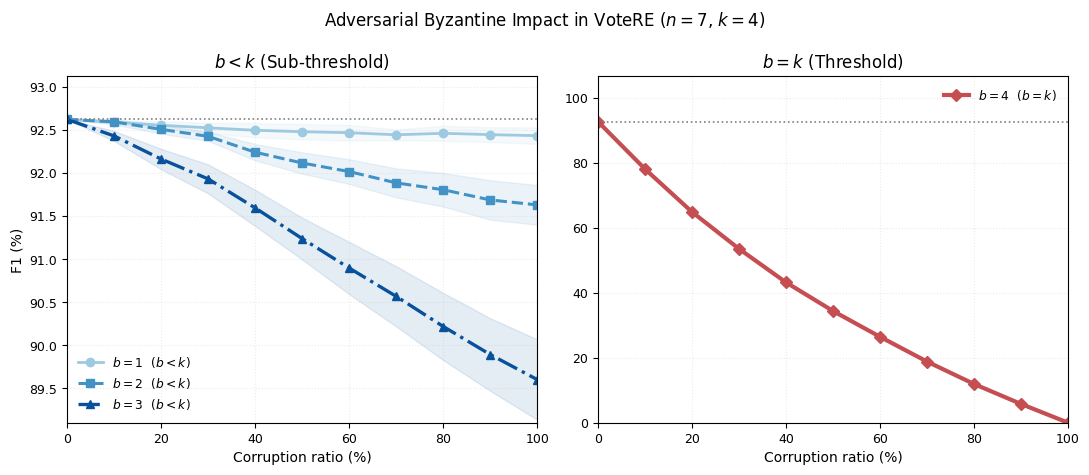

In [5]:
import io
import random
from pathlib import Path
from collections import Counter
from contextlib import redirect_stdout
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scorer


# =========================================================
# CONFIGURATION
# =========================================================
BASE_DIR = Path("Data/3_Voters_Predictions")

DATASET = "ReTACRED"   # TACRED / TACREV / ReTACRED
SPLIT = "test"         # dev / test

VOTERS = [
    "LORA_QWEN",
    "LORA_LLAMA",
    "LORA_MISTRAL",
    "PLM_BERT_LARGE",
    "PLM_DEBERTA_LARGE",
    "PLM_ROBERTA_LARGE",
    "PLM_SPANBERT_LARGE",
]

N_VOTERS = len(VOTERS)   # = 7
K = 4
FALLBACK = "no_relation"
SEED = 42

ATTACK_RATES = np.linspace(0.0, 1.0, 11).tolist()

# Only adversarial Byzantine
BYZANTINE_TYPE = "adversarial_voter"

# Figures requested
B_UNDER_K = [1, 2, 3]
B_AT_K = [4]

SAVE_FIG = True
SAVE_TABLES = True

DETAIL_CSV = f"votere_adversarial_only_n{N_VOTERS}_k{K}_detailed_{DATASET.lower()}_{SPLIT}.csv"
SUMMARY_CSV = f"votere_adversarial_only_n{N_VOTERS}_k{K}_summary_{DATASET.lower()}_{SPLIT}.csv"

FIG_UNDER_K = f"votere_adversarial_under_k_n{N_VOTERS}_k{K}_{DATASET.lower()}_{SPLIT}.png"
FIG_AT_K = f"votere_adversarial_at_k_n{N_VOTERS}_k{K}_{DATASET.lower()}_{SPLIT}.png"

random.seed(SEED)
np.random.seed(SEED)


# =========================================================
# HELPERS
# =========================================================
def silent_score(gold, pred):
    buffer = io.StringIO()
    with redirect_stdout(buffer):
        p, r, f1 = scorer.score(gold, pred, verbose=False)
    return p * 100, r * 100, f1 * 100


def detect_prediction_column(df):
    if "LLM_Prediction" in df.columns:
        return "LLM_Prediction"
    if "Prediction" in df.columns:
        return "Prediction"
    raise ValueError("No prediction column found. Expected 'LLM_Prediction' or 'Prediction'.")


def load_voter_predictions(base_dir, dataset, split, voters):
    gold_reference = None
    voter_predictions = {}

    for voter in voters:
        file_path = Path(base_dir) / voter / dataset / f"{split}.csv"
        if not file_path.exists():
            raise FileNotFoundError(f"Missing file: {file_path}")

        df = pd.read_csv(file_path)
        pred_col = detect_prediction_column(df)

        if "True_Labels" not in df.columns:
            raise ValueError(f"'True_Labels' column not found in {file_path}")

        gold = df["True_Labels"].tolist()
        preds = df[pred_col].tolist()

        if gold_reference is None:
            gold_reference = gold
        else:
            if gold_reference != gold:
                raise ValueError(f"Gold mismatch detected in {file_path}")

        voter_predictions[voter] = preds

    return gold_reference, voter_predictions


def majority_vote(preds, k=4, fallback="no_relation"):
    counts = Counter(preds)
    label, count = counts.most_common(1)[0]
    return label if count >= k else fallback


def build_baseline_votere_predictions(voter_predictions, voters, k=4, fallback="no_relation"):
    n = len(next(iter(voter_predictions.values())))
    outputs = []

    for i in range(n):
        preds_i = [voter_predictions[v][i] for v in voters]
        outputs.append(majority_vote(preds_i, k=k, fallback=fallback))

    return outputs


def get_label_space(gold, voter_predictions):
    labels = set(gold)
    for preds in voter_predictions.values():
        labels.update(preds)
    return sorted(labels)


def sample_wrong_label(label_space, forbidden):
    candidates = [lab for lab in label_space if lab not in forbidden]
    if not candidates:
        return FALLBACK
    return random.choice(candidates)


def build_fixed_scenario_orders(max_b, n, seed=42):
    """
    Fixed attack order per number of Byzantine voters.
    This ensures nested corruption sets across attack rates.
    """
    orders = {}
    for b in range(1, max_b + 1):
        rng = np.random.RandomState(seed + 1000 + b)
        orders[b] = rng.permutation(n)
    return orders


def get_attacked_indices(order, attack_rate, n):
    n_attacked = int(round(attack_rate * n))
    if n_attacked <= 0:
        return set()
    return set(order[:n_attacked])


# =========================================================
# COORDINATED ADVERSARIAL BYZANTINE
# =========================================================
def coordinated_adversarial_label(gold_label, honest_preds, label_space):
    """
    Shared malicious label used by all Byzantine voters on one instance.
    """
    if len(honest_preds) > 0 and len(set(honest_preds)) == 1:
        honest_label = honest_preds[0]
        return sample_wrong_label(
            label_space=label_space,
            forbidden={gold_label, honest_label}
        )

    honest_counts = Counter(honest_preds) if len(honest_preds) > 0 else Counter()
    honest_majority = honest_counts.most_common(1)[0][0] if len(honest_counts) > 0 else None

    forbidden = {gold_label}
    if honest_majority is not None:
        forbidden.add(honest_majority)

    return sample_wrong_label(label_space, forbidden)


def inject_coordinated_adversarial(
    voter_predictions,
    voters,
    faulty_voters,
    attack_rate,
    gold,
    label_space,
    scenario_attack_order
):
    modified = {v: list(preds) for v, preds in voter_predictions.items()}
    n = len(gold)

    attacked_indices = get_attacked_indices(scenario_attack_order, attack_rate, n)
    faulty_voters = list(faulty_voters)
    honest_voters = [v for v in voters if v not in faulty_voters]

    for i in attacked_indices:
        honest_preds = [voter_predictions[v][i] for v in honest_voters]
        gold_label = gold[i]

        malicious_label = coordinated_adversarial_label(
            gold_label=gold_label,
            honest_preds=honest_preds,
            label_space=label_space
        )

        for faulty_voter in faulty_voters:
            modified[faulty_voter][i] = malicious_label

    return modified, attacked_indices


# =========================================================
# LOAD DATA
# =========================================================
gold, voter_predictions = load_voter_predictions(BASE_DIR, DATASET, SPLIT, VOTERS)
label_space = get_label_space(gold, voter_predictions)
n = len(gold)

scenario_attack_orders = build_fixed_scenario_orders(N_VOTERS, n, seed=SEED)

print(f"Loaded {n} instances")
print(f"Dataset: {DATASET} | Split: {SPLIT}")
print(f"Voters ({N_VOTERS}): {VOTERS}")
print(f"Threshold k = {K}")


# =========================================================
# BASELINE
# =========================================================
baseline_preds = build_baseline_votere_predictions(
    voter_predictions, VOTERS, k=K, fallback=FALLBACK
)
base_p, base_r, base_f1 = silent_score(gold, baseline_preds)

print("\nBaseline VoteRE:")
print(f"P={base_p:.2f} | R={base_r:.2f} | F1={base_f1:.2f}")


# =========================================================
# ADVERSARIAL ANALYSIS FOR b = 1,2,3,4
# =========================================================
rows = []

SCENARIOS = {
    b: list(combinations(VOTERS, b))
    for b in (B_UNDER_K + B_AT_K)
}

for num_byzantine, faulty_sets in SCENARIOS.items():
    print(f"\nProcessing adversarial Byzantine with b = {num_byzantine} ...")

    for faulty_voters in faulty_sets:
        faulty_voters = tuple(faulty_voters)

        for attack_rate in ATTACK_RATES:
            attacked_preds_dict, attacked_indices = inject_coordinated_adversarial(
                voter_predictions=voter_predictions,
                voters=VOTERS,
                faulty_voters=faulty_voters,
                attack_rate=attack_rate,
                gold=gold,
                label_space=label_space,
                scenario_attack_order=scenario_attack_orders[num_byzantine]
            )

            attacked_final = []
            changed = 0
            harmful = 0

            for i in range(n):
                preds_i = [attacked_preds_dict[v][i] for v in VOTERS]
                final_i = majority_vote(preds_i, k=K, fallback=FALLBACK)
                attacked_final.append(final_i)

                if i in attacked_indices:
                    if final_i != baseline_preds[i]:
                        changed += 1
                    if baseline_preds[i] == gold[i] and final_i != gold[i]:
                        harmful += 1

            p, r, f1 = silent_score(gold, attacked_final)

            rows.append({
                "num_byzantine": num_byzantine,
                "faulty_voters": "+".join(faulty_voters),
                "attack_rate": attack_rate,
                "P": p,
                "R": r,
                "F1": f1,
                "delta_F1": base_f1 - f1,
                "change_rate": 100 * changed / max(len(attacked_indices), 1),
                "harmful_change_rate": 100 * harmful / max(len(attacked_indices), 1),
                "regime": "under_k" if num_byzantine < K else "at_k",
            })

results_df = pd.DataFrame(rows)

summary_df = (
    results_df.groupby(["num_byzantine", "attack_rate"])
    .agg(
        P_mean=("P", "mean"),
        P_std=("P", "std"),
        R_mean=("R", "mean"),
        R_std=("R", "std"),
        F1_mean=("F1", "mean"),
        F1_std=("F1", "std"),
        DeltaF1_mean=("delta_F1", "mean"),
        Change_mean=("change_rate", "mean"),
        Harmful_mean=("harmful_change_rate", "mean"),
    )
    .reset_index()
    .fillna(0)
)

print("\nSummary:")
print(summary_df)

if SAVE_TABLES:
    results_df.to_csv(DETAIL_CSV, index=False)
    summary_df.to_csv(SUMMARY_CSV, index=False)


# =========================================================
# PLOT STYLE
# =========================================================
plt.rcParams.update({
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "legend.fontsize": 8.8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

UNDER_K_STYLE = {
    1: {"color": "#9ECAE1", "marker": "o", "linewidth": 2.0, "linestyle": "-"},
    2: {"color": "#4292C6", "marker": "s", "linewidth": 2.2, "linestyle": "--"},
    3: {"color": "#08519C", "marker": "^", "linewidth": 2.4, "linestyle": "-."},
}

AT_K_STYLE = {
    4: {"color": "#C44E52", "marker": "D", "linewidth": 3.0, "linestyle": "-"},
}

DISPLAY_NAMES = {
    1: r"$b=1$  ($b<k$)",
    2: r"$b=2$  ($b<k$)",
    3: r"$b=3$  ($b<k$)",
    4: r"$b=4$  ($b=k$)",
}




# =========================================================
# ONE FIGURE WITH 2 PANELS (LEFT: b<k, RIGHT: b=k)
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), sharex=True)

# -------------------------
# LEFT PANEL: b < k
# -------------------------
ax_left = axes[0]

for b in B_UNDER_K:
    sub = summary_df[summary_df["num_byzantine"] == b].sort_values("attack_rate")

    x = sub["attack_rate"].values * 100
    y = sub["F1_mean"].values
    y_std = sub["F1_std"].values

    style = UNDER_K_STYLE[b]

    ax_left.plot(
        x, y,
        color=style["color"],
        marker=style["marker"],
        linewidth=style["linewidth"],
        linestyle=style["linestyle"],
        markersize=6,
        label=DISPLAY_NAMES[b]
    )

    ax_left.fill_between(
        x,
        y - y_std,
        y + y_std,
        color=style["color"],
        alpha=0.10
    )

# Baseline
ax_left.axhline(base_f1, color="gray", linestyle=":", linewidth=1.2)

ax_left.set_title(r"$b < k$ (Sub-threshold)")
ax_left.set_xlabel("Corruption ratio (%)")
ax_left.set_ylabel("F1 (%)")
ax_left.set_xlim(0, 100)
ax_left.set_xticks([0, 20, 40, 60, 80, 100])
ax_left.grid(True, linestyle=":", alpha=0.25)

# Zoom scale (important)
under_df = summary_df[summary_df["num_byzantine"].isin(B_UNDER_K)]
y_under = under_df["F1_mean"].tolist() + [base_f1]
margin = max(0.5, 0.08 * (max(y_under) - min(y_under)))
ax_left.set_ylim(min(y_under) - margin, max(y_under) + margin)

ax_left.legend(frameon=False, loc="best")


# -------------------------
# RIGHT PANEL: b = k
# -------------------------
ax_right = axes[1]

for b in B_AT_K:
    sub = summary_df[summary_df["num_byzantine"] == b].sort_values("attack_rate")

    x = sub["attack_rate"].values * 100
    y = sub["F1_mean"].values
    y_std = sub["F1_std"].values

    style = AT_K_STYLE[b]

    ax_right.plot(
        x, y,
        color=style["color"],
        marker=style["marker"],
        linewidth=style["linewidth"],
        linestyle=style["linestyle"],
        markersize=6.5,
        label=DISPLAY_NAMES[b]
    )

    ax_right.fill_between(
        x,
        y - y_std,
        y + y_std,
        color=style["color"],
        alpha=0.15
    )

# Baseline
ax_right.axhline(base_f1, color="gray", linestyle=":", linewidth=1.2)

ax_right.set_title(r"$b = k$ (Threshold)")
ax_right.set_xlabel("Corruption ratio (%)")
ax_right.set_xlim(0, 100)
ax_right.set_xticks([0, 20, 40, 60, 80, 100])
ax_right.grid(True, linestyle=":", alpha=0.25)

# Separate scale (VERY IMPORTANT)
sub_k = summary_df[summary_df["num_byzantine"] == K]
y_k = sub_k["F1_mean"].tolist() + [base_f1]
margin_k = max(1.0, 0.15 * (max(y_k) - min(y_k)))
ax_right.set_ylim(max(0, min(y_k) - margin_k), max(y_k) + margin_k)

ax_right.legend(frameon=False, loc="best")


# -------------------------
# GLOBAL TITLE
# -------------------------
fig.suptitle(r"Adversarial Byzantine Impact in VoteRE ($n=7$, $k=4$)", fontsize=12)

plt.tight_layout()

if SAVE_FIG:
    plt.savefig("votere_two_regimes_one_row.png", dpi=300, bbox_inches="tight")

plt.show()